# Parameter Estimation

We have learned how to compute numerically the behavior of a system given well known initial conditions and parameter values. In most practical cases, though, we don't have the luxury of knowing the values of all such quantities. Most likely, we only gathered time-series measurements of the variables in our model and we want to reconstruct from the data itself the appropriate parameter values.

In this notebook we will study two approaches to such task: grid search and gradient-descent optimizations.

First, we need some setup work: we import libraries for numerical computing and plotting, then we customize graphical parameters.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
%matplotlib inline

In [3]:
mpl.rc('figure', figsize=(14,7))

## Historical Data

We load some historical data from the `sir` package with the following code. A plot will help us visualize time-dependent behavior.

In [4]:
import sir

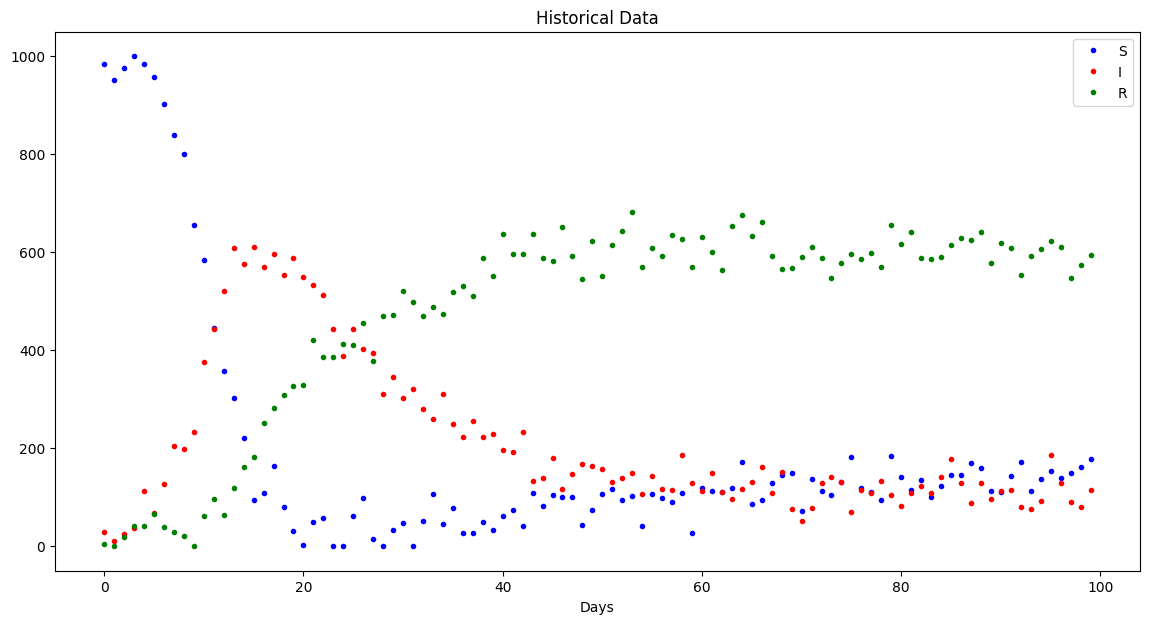

In [5]:
H = sir.historical_data()
T = np.arange(H.shape[0])

for i in range(3):
    plt.plot(T, H[:, i], '.', color='brg'[i], label='SIR'[i])
    
plt.legend(loc='upper right')
plt.title('Historical Data')
plt.xlabel('Days')
plt.show()

## Grid Search

The first requirement to implement grid search is a function to compute the model equations (we discussed the definition of the `sir_eq` function previously).

In [6]:
def sir_eq(pop, t, rb, rd, ri, rr, rs):
    s, i, r = pop

    return ( rb + rs*r - ri*s*i,
             ri*s*i - rr*i - rd*i,
             rr*i - rs*r )

We are going to use an *SSE* score to decide which choice of parameter values works best in our study. SSE is defined as the sum of the squared differences between obserations $O$ and predictions $P$. The function below implements this measure.

In [7]:
def sse(O, P):
    return np.sum((O-P)**2)

We can associate to a choice of parameter values a specific score, like this:

In [8]:
p0 = (900, 10, 0)
params = (4, .02, .00045, .051, 0.05)
P = odeint(sir_eq, p0, T, params)
sse(H, P)

8431399.918411624

Now we need to identify:
1. the expected minimum and maximum value of each parameter;
2. the number of points inside such ranges at which we want to evaluate the behavior of the model.

For instance, we will let $r_b$ (rate of birth) range from $0$ to $10$ and we will consider 8 different points inside such interval.

In [9]:
np.linspace(0, 10, 8)  # rb values we will test

array([ 0.        ,  1.42857143,  2.85714286,  4.28571429,  5.71428571,
        7.14285714,  8.57142857, 10.        ])

Our model contains 5 parameters, so we will take all the combinations of their possibile values.

In [10]:
params = sir.combinations(
    np.linspace(0, 10, 8),
    np.linspace(0, 0.1, 8),
    np.linspace(1e-4, 1e-3, 8),
    np.linspace(0.01, 0.1, 8),
    np.linspace(0, 0.05, 8),
)

The total number of cases we need to consider is already quite large.

In [11]:
len(params)

32768

In [12]:
%%time
best_params = None
smallest_sse = np.inf

for choice in params:
    P = odeint(sir_eq, p0, T, tuple(choice))
    score = sse(H, P)
    
    if score < smallest_sse:
        best_params = choice
        smallest_sse = score

CPU times: user 1min 25s, sys: 2.13 s, total: 1min 28s
Wall time: 3min 17s


In [13]:
best_params

array([2.85714286e+00, 1.42857143e-02, 4.85714286e-04, 4.85714286e-02,
       7.14285714e-03])

In [14]:
smallest_sse

581247.8924567802

Did the search work? Let's make a plot of the historical observations *vs* the predictions with the optimized parameters.

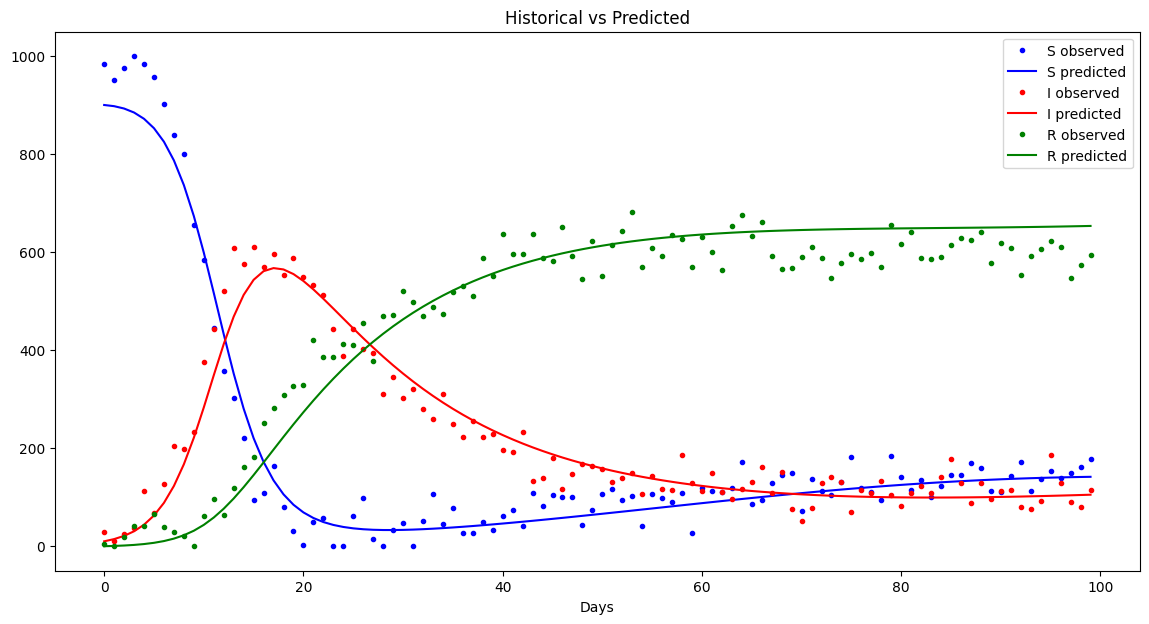

In [15]:
P = odeint(sir_eq, p0, T, tuple(best_params))

for i in range(3):
    plt.plot(T, H[:, i], '.', color='brg'[i], label='SIR'[i] + ' observed')
    plt.plot(T, P[:, i], color='brg'[i], label='SIR'[i] + ' predicted')
    
plt.legend(loc='upper right')
plt.title('Historical vs Predicted')
plt.xlabel('Days')
plt.show()

## Gradient-Descent Search

We now turn our attention to a different type of optimization strategy called *gradient-descent* search. Lucky for us, the *scipy* library already implements this type of algorithm.

In [16]:
from scipy.optimize import minimize

The `minimize` function takes two arguments:
1. a function `eval_sse` which computes the *SSE* for a given choice of parameter values;
2. an initial guess for the parameters.

In [17]:
def eval_sse(params):
    p0 = params[:3]
    params = tuple(params[3:])

    sim = odeint(sir_eq, p0, T, params)
    return sse(H, sim)

In [18]:
initial_guess = (1000, 10, 5, 1,.1,.1,.1,.1)

Note that in the vector above we have merged initial population sizes with parameters. Gradient descent will thus estimate those initial sizes from the data itself as part of its search procedure.

In [19]:
res = minimize(eval_sse, initial_guess)
res

/Users/border/Documents/Working/Systems Biology/.venv/lib/python3.10/site-packages/scipy/integrate/_odepack_py.py:247: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
/var/folders/xc/g5pbrt4n3cb0cbzl1jpph_h40000gn/T/ipykernel_37077/2892089721.py:2: RuntimeWarning: overflow encountered in square
  return np.sum((O-P)**2)
/Users/border/Documents/Working/Systems Biology/.venv/lib/python3.10/site-packages/scipy/integrate/_odepack_py.py:247: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)


      fun: 11618127.71881393
 hess_inv: array([[ 2.36932151e-06, -3.21588484e-07, -3.70648122e-07,
         2.22531599e-06,  8.69028007e-09, -2.38775619e-06,
        -1.97867548e-08, -3.97896012e-09],
       [-3.21588476e-07,  6.82356031e-08,  2.72049781e-08,
        -2.90180427e-07, -9.17326717e-10,  3.24104903e-07,
         2.70396505e-09,  5.56931561e-10],
       [-3.70648156e-07,  2.72049803e-08,  8.00714929e-08,
        -3.61156041e-07, -1.59251570e-09,  3.73429933e-07,
         2.98134614e-09,  5.74106208e-10],
       [ 2.22531615e-06, -2.90180434e-07, -3.61156056e-07,
         2.10726564e-06,  8.24466170e-09, -2.24254261e-06,
        -1.84855750e-08, -3.72411447e-09],
       [ 8.69028043e-09, -9.17326730e-10, -1.59251577e-09,
         8.24466193e-09,  5.51769071e-11, -8.77770432e-09,
        -9.41274328e-11, -2.09013037e-11],
       [-2.38775619e-06,  3.24104911e-07,  3.73429899e-07,
        -2.24254244e-06, -8.77770396e-09,  2.40643272e-06,
         2.00479056e-08,  4.03971693e

The result produced by `minimize` is quite complicated, but there is a line which immediately stands out:

> success: False

It looks like the procedure was not successful. Let's double check it with a plot.

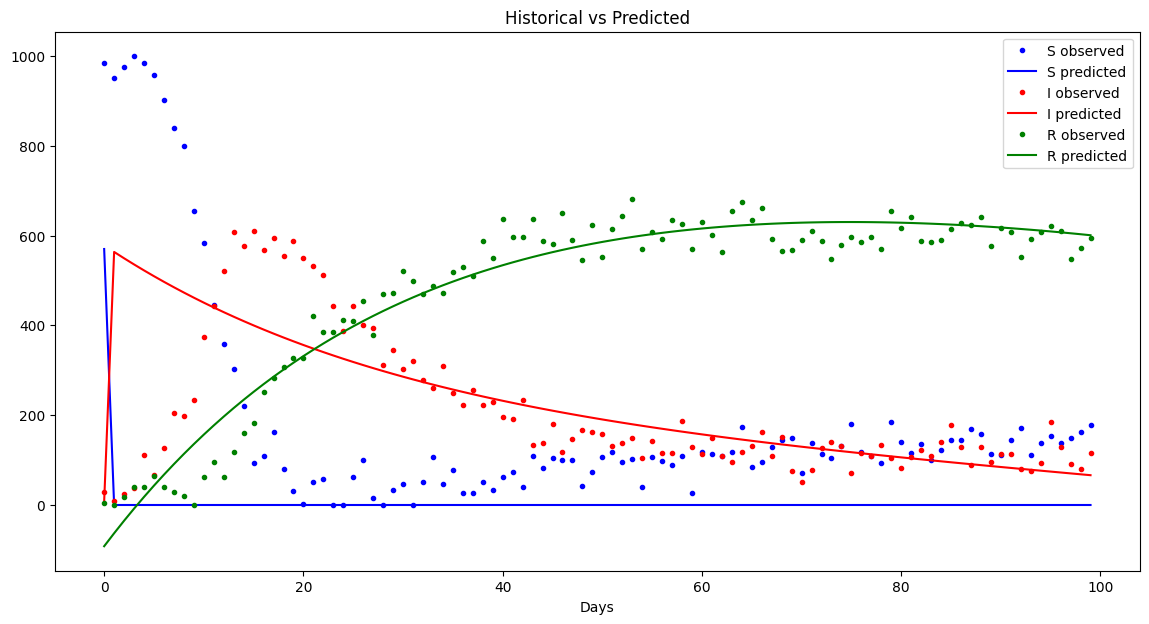

In [20]:
P = odeint(sir_eq, res.x[:3], T, tuple(res.x[3:]))

for i in range(3):
    plt.plot(T, H[:, i], '.', color='brg'[i], label='SIR'[i] + ' observed')
    plt.plot(T, P[:, i], color='brg'[i], label='SIR'[i] + ' predicted')
    
plt.legend(loc='upper right')
plt.title('Historical vs Predicted')
plt.xlabel('Days')
plt.show()

It is instructive, to understand what is really going on, to make the code more verbose. Let's make it print every parameter combination that is tested out.

In [21]:
def eval_sse_verbose(params):
    p0 = params[:3]
    params = tuple(params[3:])
    print(params)

    sim = odeint(sir_eq, p0, T, params)
    return sse(H, sim)

minimize(eval_sse_verbose, initial_guess)

(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0000000149011612, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1000000149011612, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1000000149011612, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1000000149011612, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1000000149011612)
(0.9793470675086705, -0.5715397517148668, 0.41659896042106226, 0.5410643940560297, -0.2975979041177864)


/Users/border/Documents/Working/Systems Biology/.venv/lib/python3.10/site-packages/scipy/integrate/_odepack_py.py:247: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)


(0.9793470675086705, -0.5715397517148668, 0.41659896042106226, 0.5410643940560297, -0.2975979041177864)
(0.9793470675086705, -0.5715397517148668, 0.41659896042106226, 0.5410643940560297, -0.2975979041177864)
(0.9793470675086705, -0.5715397517148668, 0.41659896042106226, 0.5410643940560297, -0.2975979041177864)
(0.9793470824098317, -0.5715397517148668, 0.41659896042106226, 0.5410643940560297, -0.2975979041177864)
(0.9793470675086705, -0.5715397368137056, 0.41659896042106226, 0.5410643940560297, -0.2975979041177864)
(0.9793470675086705, -0.5715397517148668, 0.41659897532222345, 0.5410643940560297, -0.2975979041177864)
(0.9793470675086705, -0.5715397517148668, 0.41659896042106226, 0.5410644089571909, -0.2975979041177864)
(0.9793470675086705, -0.5715397517148668, 0.41659896042106226, 0.5410643940560297, -0.2975978892166252)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.1, 0.1, 0.1, 0.1)
(1.0000000149011612, 0.1, 0.1, 0.1, 0.1)
(1.0, 0.100000014901161

/Users/border/Documents/Working/Systems Biology/.venv/lib/python3.10/site-packages/scipy/integrate/_odepack_py.py:247: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)


(0.9948367668771676, -0.0678849379287167, 0.17914974010526558, 0.2102660985140074, 0.0006005239705533932)
(0.9965578449416089, -0.011923280349967896, 0.1527664879334804, 0.17351072472219348, 0.03373368951652264)
(0.9980213093607468, 0.03566194916085391, 0.13033232203927647, 0.1422569525268593, 0.061907431237920925)
(0.9980213093607468, 0.03566194916085391, 0.13033232203927647, 0.1422569525268593, 0.061907431237920925)
(0.9980213093607468, 0.03566194916085391, 0.13033232203927647, 0.1422569525268593, 0.061907431237920925)
(0.9980213093607468, 0.03566194916085391, 0.13033232203927647, 0.1422569525268593, 0.061907431237920925)
(0.998021324261908, 0.03566194916085391, 0.13033232203927647, 0.1422569525268593, 0.061907431237920925)
(0.9980213093607468, 0.035661964062015106, 0.13033232203927647, 0.1422569525268593, 0.061907431237920925)
(0.9980213093607468, 0.03566194916085391, 0.13033233694043767, 0.1422569525268593, 0.061907431237920925)
(0.9980213093607468, 0.03566194916085391, 0.130332322

      fun: 11618127.71881393
 hess_inv: array([[ 2.36932151e-06, -3.21588484e-07, -3.70648122e-07,
         2.22531599e-06,  8.69028007e-09, -2.38775619e-06,
        -1.97867548e-08, -3.97896012e-09],
       [-3.21588476e-07,  6.82356031e-08,  2.72049781e-08,
        -2.90180427e-07, -9.17326717e-10,  3.24104903e-07,
         2.70396505e-09,  5.56931561e-10],
       [-3.70648156e-07,  2.72049803e-08,  8.00714929e-08,
        -3.61156041e-07, -1.59251570e-09,  3.73429933e-07,
         2.98134614e-09,  5.74106208e-10],
       [ 2.22531615e-06, -2.90180434e-07, -3.61156056e-07,
         2.10726564e-06,  8.24466170e-09, -2.24254261e-06,
        -1.84855750e-08, -3.72411447e-09],
       [ 8.69028043e-09, -9.17326730e-10, -1.59251577e-09,
         8.24466193e-09,  5.51769071e-11, -8.77770432e-09,
        -9.41274328e-11, -2.09013037e-11],
       [-2.38775619e-06,  3.24104911e-07,  3.73429899e-07,
        -2.24254244e-06, -8.77770396e-09,  2.40643272e-06,
         2.00479056e-08,  4.03971693e

The exact output is going to change every time you run che code above, as the gradiend descent procedure is inherently stochastic (it uses random numbers). Still, you will usually find some **negative** parameter values.

In general, negative values are perfectly fine and the search procedure should test them. In our model, however, they should not appear. What would be the meaning of a negative rate of infection?

We can help `minimize` by making this requirement explicit through *bounds*.

In [22]:
res = minimize(eval_sse,
               initial_guess,
               bounds = [
                 (900, 1100),
                 (0, 50),
                 (0, 25),
                 (1, 5), (0, 1), (0, 1), (0, 1), (0, 1)
               ])
res

      fun: 266131.162221319
 hess_inv: <8x8 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 1.97905890e-01,  1.37346798e+02, -2.75723871e+02, -6.81029637e-01,
        2.42324313e+02,  9.88405081e+03,  1.09570101e+02, -6.12868462e+01])
  message: 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 1134
      nit: 66
     njev: 126
   status: 0
  success: True
        x: array([9.81067529e+02, 7.68490590e+00, 3.86117136e+00, 2.91713916e+00,
       2.00280144e-02, 5.24007487e-04, 5.07611582e-02, 9.97685091e-03])

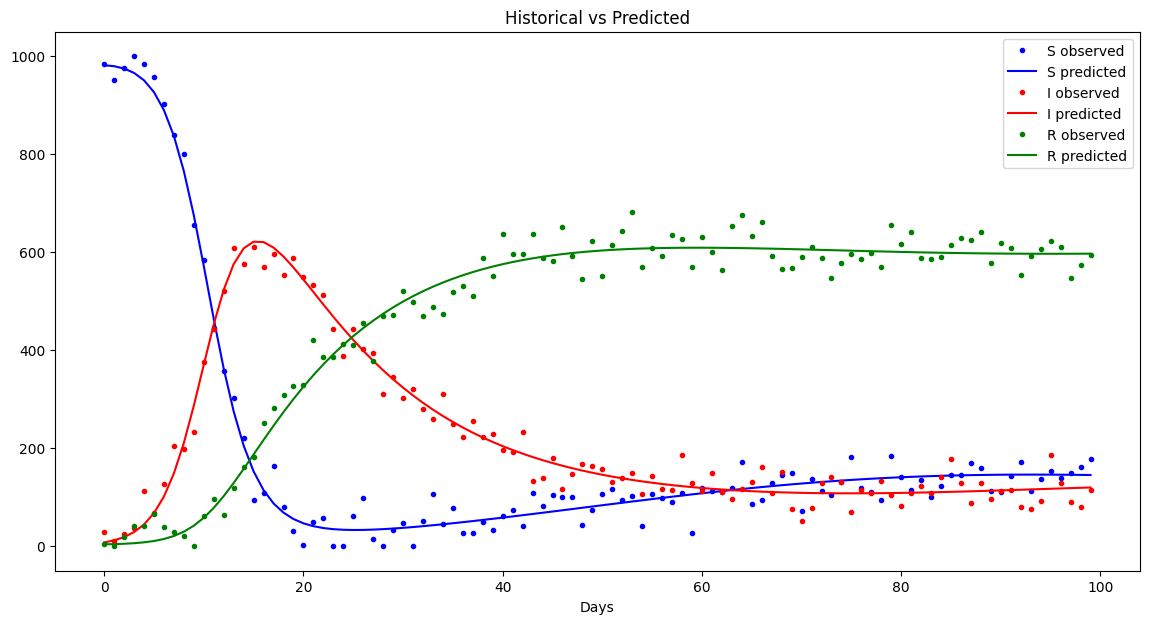

In [23]:
P = odeint(sir_eq, res.x[:3], T, tuple(res.x[3:]))

for i in range(3):
    plt.plot(T, H[:, i], '.', color='brg'[i], label='SIR'[i] + ' observed')
    plt.plot(T, P[:, i], color='brg'[i], label='SIR'[i] + ' predicted')
    
plt.legend(loc='upper right')
plt.title('Historical vs Predicted')
plt.xlabel('Days')
plt.show()